<a href="https://colab.research.google.com/github/eugeniatate-duke/XAI-mlcourt-recidivism/blob/main/mlcourt_recidivism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ⚖️ Case 3: Recidivism Risk – COMPAS Dataset
#### 🔍 Scenario
Malik Johnson, a 27-year-old with one prior felony, was flagged as low risk by an AI risk assessment tool and granted parole. Some community stakeholders have questioned whether this was an appropriate classification.

#### 🟥 Prosecution
Examine whether the model may have underestimated risk factors. Use explanation techniques to uncover potential oversights or inconsistencies.

#### 🟦 Defense
Argue that the decision was reasonable based on the model's criteria. Use explanation tools to show which features were most influential and whether the classification aligns with data-driven patterns.

In [10]:
# ⚖️ Case 3: Recidivism Prediction (COMPAS Dataset)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df_compas = pd.read_csv(url)

# Filter relevant columns and preprocess
features = ['age', 'sex', 'race', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree']
df = df_compas[features + ['two_year_recid']].dropna()
df = df[df['c_charge_degree'].isin(['F', 'M'])]  # Filter valid degrees

# Encode categoricals
df = df.copy()
df['sex'] = df['sex'].astype('category').cat.codes
df['race'] = df['race'].astype('category').cat.codes
df['c_charge_degree'] = df['c_charge_degree'].astype('category').cat.codes

X = df[features]
y = df['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_compas = RandomForestClassifier(random_state=42)
model_compas.fit(X_train, y_train)
print(classification_report(y_test, model_compas.predict(X_test)))


              precision    recall  f1-score   support

           0       0.68      0.68      0.68       823
           1       0.57      0.57      0.57       620

    accuracy                           0.63      1443
   macro avg       0.62      0.62      0.62      1443
weighted avg       0.63      0.63      0.63      1443



In [11]:
print("Training examples:", len(X_train))
print("Test examples:", len(X_test))

display(X_train.head())

print("Training outcome proportions:")
print(y_train.value_counts(normalize=True).sort_index())

Training examples: 5771
Test examples: 1443


,age,sex,race,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree
3307,28,1,2,2,0,0,0,0
911,46,1,0,2,0,0,0,0
6532,22,0,0,0,0,0,0,1
6233,26,1,0,1,0,0,0,0
3355,21,1,2,0,0,0,0,0


Training outcome proportions:
two_year_recid
0    0.5441
1    0.4559
Name: proportion, dtype: float64


In [12]:
# Recover category mappings using the same rows and encoding
# procedure as the original training cell.
categorical_columns = ["sex", "race", "c_charge_degree"]

original_values = df_compas[features + ["two_year_recid"]].dropna()
original_values = original_values[
    original_values["c_charge_degree"].isin(["F", "M"])
]

category_mappings = {}

for column in categorical_columns:
    categories = original_values[column].astype("category").cat.categories
    category_mappings[column] = dict(enumerate(categories))

    print(f"{column}: {category_mappings[column]}")

sex: {0: 'Female', 1: 'Male'}
race: {0: 'African-American', 1: 'Asian', 2: 'Caucasian', 3: 'Hispanic', 4: 'Native American', 5: 'Other'}
c_charge_degree: {0: 'F', 1: 'M'}


In [13]:
# 🎯 Focus Instance: Recidivism Risk Case (Malik Johnson)
focus_instance_compas = pd.DataFrame([{
    "age": 27,
    "sex": 1,  # Male
    "race": 1,  # African-American
    "priors_count": 1,
    "juv_fel_count": 0,
    "juv_misd_count": 0,
    "juv_other_count": 0,
    "c_charge_degree": 1  # Felony
}])

pred = model_compas.predict(focus_instance_compas)
print("Prediction for Malik Johnson (Recidivism):", pred)


Prediction for Malik Johnson (Recidivism): [0]


In [14]:
# to ensure input columns match the model's training order
malik = focus_instance_compas[X_train.columns].copy()

# display readable category names instead of integers
readable_malik = malik.copy()

for column in categorical_columns:
    readable_malik[column] = malik[column].map(category_mappings[column])

display(readable_malik)

# predicted class and the model's probability for each class
prediction = model_compas.predict(malik)[0]
probabilities = model_compas.predict_proba(malik)[0]

print("Predicted class:", prediction)

for label, probability in zip(model_compas.classes_, probabilities):
    print(f"Model probability for class {label}: {probability:.3f}")

,age,sex,race,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree
0,27,Male,Asian,1,0,0,0,M


Predicted class: 0
Model probability for class 0: 0.901
Model probability for class 1: 0.099


In [15]:
%pip install -q shap

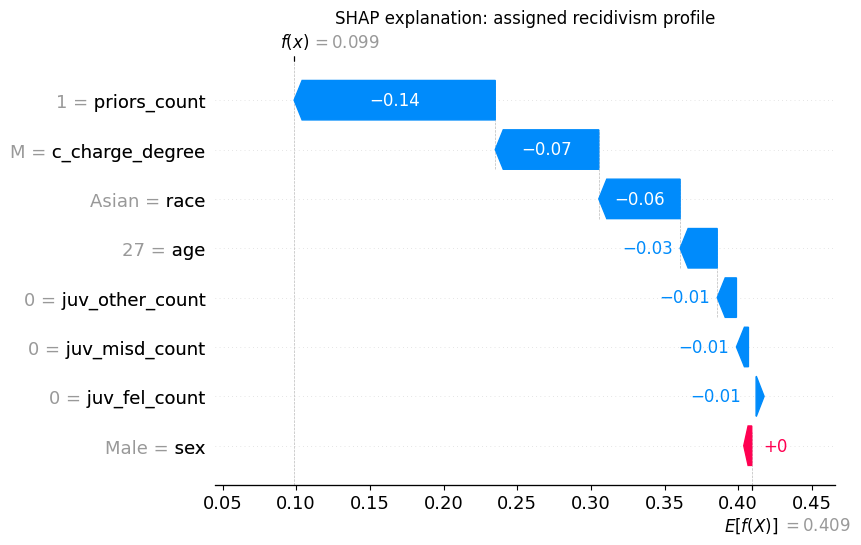

In [16]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# explain class 1: recorded recidivism
# finding class position to avoid assuming the output order
class_1_index = list(model_compas.classes_).index(1)

# using training examples as the reference population
# random seed makes the reference sample reproducible
background = X_train.sample(n=100, random_state=42)

# TreeExplainer: "probability" makes the contributions interpretable in probability units
explainer_shap = shap.TreeExplainer(
    model_compas,
    data=background,
    feature_perturbation="interventional",
    model_output="probability"
)

# compute contributions for Malik's assigned numeric profile
shap_results = explainer_shap(malik)

# select the first person and the class-1 explanation
malik_shap = shap_results[0, :, class_1_index]

# display readable category names on the plot
readable_explanation = shap.Explanation(
    values=malik_shap.values,
    base_values=malik_shap.base_values,
    data=readable_malik.iloc[0].to_numpy(),
    feature_names=malik.columns.tolist()
)

shap.plots.waterfall(
    readable_explanation,
    max_display=len(malik.columns),
    show=False
)

plt.title("SHAP explanation: assigned recidivism profile")
plt.show()

SHAP explains the assigned profile’s predicted recidivism probability of 9.9% relative to a background prediction of 40.9%. One prior offense and a current misdemeanor charge provide the largest downward contributions, approximately 13.7 and 7.0 percentage points, respectively. The absence of recorded juvenile offenses also lowers the prediction. These findings support a limited defense that the classification is consistent with the model’s learned patterns. However, the race category “Asian” contributes approximately 5.5 percentage points downward, preventing a claim that the prediction is based solely on criminal history. These attributions explain model behavior; they do not establish fairness, causal effects, or the individual’s future outcome.

In [17]:
# SHAP should reconstruct the model's probability:
# baseline + all feature contributions = predicted probability.
baseline = float(malik_shap.base_values)
contributions = malik_shap.values
model_probability = model_compas.predict_proba(malik)[0, class_1_index]

print(f"SHAP baseline: {baseline:.3f}")
print(f"Sum of contributions: {contributions.sum():+.3f}")
print(f"Reconstructed probability: {baseline + contributions.sum():.3f}")
print(f"Model probability: {model_probability:.3f}")

assert np.isclose(
    baseline + contributions.sum(),
    model_probability,
    atol=1e-5
)

shap_table = pd.DataFrame({
    "Feature": malik.columns,
    "Value": readable_malik.iloc[0].to_numpy(),
    "SHAP contribution": contributions
})

# Show the most influential features first, regardless of direction.
shap_table["Absolute contribution"] = (
    shap_table["SHAP contribution"].abs()
)

display(
    shap_table.sort_values("Absolute contribution", ascending=False)
    .drop(columns="Absolute contribution")
)

SHAP baseline: 0.409
Sum of contributions: -0.311
Reconstructed probability: 0.099
Model probability: 0.099


,Feature,Value,SHAP contribution
3,priors_count,1,-0.136532
7,c_charge_degree,M,-0.070256
2,race,Asian,-0.055226
0,age,27,-0.025176
6,juv_other_count,0,-0.013032
5,juv_misd_count,0,-0.008157
4,juv_fel_count,0,-0.005196
1,sex,Male,0.002954


In [18]:
%pip install -q lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


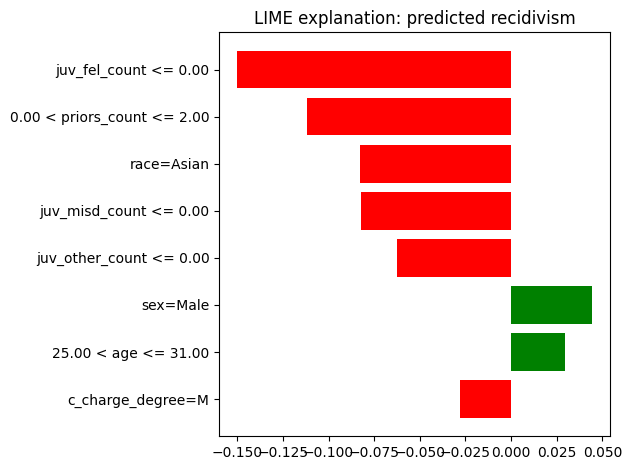

In [19]:
from lime.lime_tabular import LimeTabularExplainer

# Tell LIME which columns contain category codes.
# Otherwise, it could treat race codes as meaningful numerical quantities.
categorical_columns = ["sex", "race", "c_charge_degree"]

categorical_indices = [
    X_train.columns.get_loc(column)
    for column in categorical_columns
]

# Supply readable names in the order of their numeric codes.
lime_category_names = {
    X_train.columns.get_loc(column): [
        category_mappings[column][code]
        for code in sorted(category_mappings[column])
    ]
    for column in categorical_columns
}

explainer_lime = LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=X_train.columns.tolist(),
    class_names=[
        "No recorded recidivism",
        "Recorded recidivism"
    ],
    categorical_features=categorical_indices,
    categorical_names=lime_category_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

def predict_for_lime(samples):
    # LIME supplies an array. Restore the column names expected by our model.
    samples_df = pd.DataFrame(samples, columns=X_train.columns)
    return model_compas.predict_proba(samples_df)

# Explain class 1 again, so signs have the same meaning as in our SHAP plot.
lime_explanation = explainer_lime.explain_instance(
    data_row=malik.iloc[0].to_numpy(),
    predict_fn=predict_for_lime,
    labels=(class_1_index,),
    num_features=len(X_train.columns),
    num_samples=10000
)

lime_explanation.as_pyplot_figure(label=class_1_index)
plt.title("LIME explanation: predicted recidivism")
plt.tight_layout()
plt.show()

In [20]:
lime_table = pd.DataFrame(
    lime_explanation.as_list(label=class_1_index),
    columns=["Feature condition", "LIME weight"]
)

display(lime_table)

forest_probability = model_compas.predict_proba(malik)[0, class_1_index]
lime_probability = float(np.ravel(lime_explanation.local_pred)[0])

print(f"Forest probability: {forest_probability:.3f}")
print(f"LIME approximation: {lime_probability:.3f}")
print(f"Absolute difference: {abs(forest_probability - lime_probability):.3f}")
print(f"LIME weighted R²: {lime_explanation.score:.3f}")

,Feature condition,LIME weight
0,juv_fel_count <= 0.00,-0.150097
1,0.00 < priors_count <= 2.00,-0.111713
2,race=Asian,-0.082836
3,juv_misd_count <= 0.00,-0.082087
4,juv_other_count <= 0.00,-0.062580
5,sex=Male,0.044416
6,25.00 < age <= 31.00,0.029730
7,c_charge_degree=M,-0.027783


Forest probability: 0.099
LIME approximation: 0.298
Absolute difference: 0.200
LIME weighted R²: 0.055
